### setup

In [20]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import correlate
from statsmodels.tsa.stattools import grangercausalitytests

models = [
    "gemma3:27b",
    "llama3.3:70b",
    "gpt-oss:120b",
    'gpt-oss:20b',
    "deepseek-r1:70b",
    "qwen3:235b",
    "qwen2.5:72b",
]

In [2]:
df_vv = pd.read_csv("./results/full_agreement_code_vulnerable_victims.csv")
df_vv['datetime'] = pd.to_datetime(df_vv['datetime'])
df_ce = pd.read_csv("./results/full_agreement_code_complicit_enablers.csv")
df_ce['datetime'] = pd.to_datetime(df_ce['datetime'])

In [21]:
df_cl = pd.read_csv("./results/full_agreement_code_conditional_loyalty.csv", parse_dates=["datetime"])
df_cl['datetime'] = pd.to_datetime(df_cl['datetime'])
df_as = pd.read_csv("./results/full_agreement_code_adapted_sovereignty.csv", parse_dates=["datetime"])
df_as['datetime'] = pd.to_datetime(df_as['datetime'])

In [22]:
df_vv = df_cl
df_ce = df_as

In [23]:
db = pd.read_excel("./data/SelfSanctions.xlsx", skiprows=1)
db = db[db[db.columns[3]] == "Switzerland"]
print(len(db))
decision_cols = [i for i in db.columns if "status of decision " in i.lower()]
cols = ["Company name", "Industry", "Description of operations identified"] + decision_cols
db = db[cols]
for c in decision_cols:
    db[c] = db[c].str.replace(" – ", " - ")\
        .str.upper().fillna('')\
        .str.replace("!TO BE VERIFIED", "")\
        .apply(lambda x: x.split(" - ")[0])
db = db.map(lambda x: np.nan if isinstance(x, str) and len(x) == 0 else x)
_cols = [i+"/22" if "new" not in i.lower() else i for i in decision_cols]
_cols = [i.split("decision ")[-1].split("-")[-1] for i in _cols]
dates = pd.to_datetime(_cols, format="%d/%m/%y")

c:\chru\.venv\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


173


C:\Users\dvalko\AppData\Local\Temp\ipykernel_3240\2846544227.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  exit_completed = exit_completed.resample("1M").interpolate()


<Axes: >

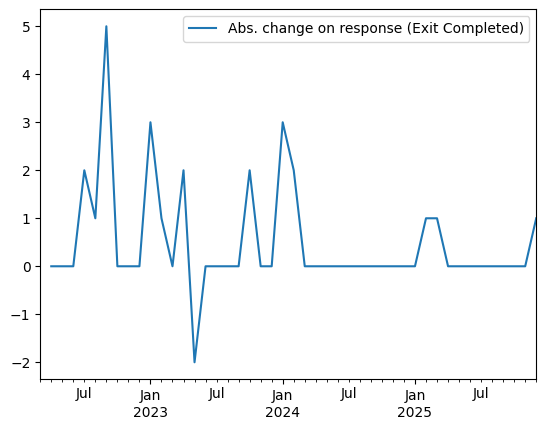

In [24]:
df_ = db.copy()
exit_completed = {}
for c, d in zip(decision_cols, dates):
    v = df_[c].map(lambda x: 1 if "EXIT COMPLETED" in str(x) else (0 if isinstance(x, str) and len(x) > 1 else np.nan))
    exit_completed[d] = v.sum()
exit_completed = pd.DataFrame(list(exit_completed.items()), columns=['Date', 'Abs. change on response (Exit Completed)']).set_index('Date')
exit_completed = exit_completed.resample("1M").interpolate()
exit_completed = exit_completed - exit_completed.shift(1)
exit_completed.plot(xlabel='')

In [25]:
vv = df_vv.copy().set_index('datetime').resample("1M").sum(numeric_only=True)['code_applied'].rename("Abs. change on signal (Vulnerable Victims)")
ce = df_ce.copy().set_index('datetime').resample("1M").sum(numeric_only=True)['code_applied'].rename("Abs. change on signal (Complicit Enablers)")
vv = vv - vv.shift(1)
ce = ce - ce.shift(1)

C:\Users\dvalko\AppData\Local\Temp\ipykernel_3240\2663467250.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  vv = df_vv.copy().set_index('datetime').resample("1M").sum(numeric_only=True)['code_applied'].rename("Abs. change on signal (Vulnerable Victims)")
C:\Users\dvalko\AppData\Local\Temp\ipykernel_3240\2663467250.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ce = df_ce.copy().set_index('datetime').resample("1M").sum(numeric_only=True)['code_applied'].rename("Abs. change on signal (Complicit Enablers)")


<Axes: >

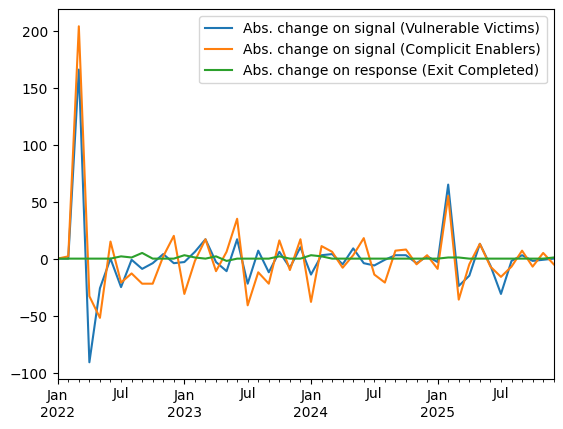

In [35]:
vv_aligned, ec_aligned = vv.align(exit_completed, fill_value=0)
vv_aligned, ce_aligned = vv.align(ce, fill_value=0)
df = pd.concat([vv_aligned, ce_aligned, exit_completed], axis=1).fillna(0)
df.plot(legend=True)

In [27]:
df[['Abs. change on signal (Vulnerable Victims)', 'Abs. change on signal (Complicit Enablers)']].corr()

,Abs. change on signal (Vulnerable Victims),Abs. change on signal (Complicit Enablers)
Abs. change on signal (Vulnerable Victims),1.00000,0.89839
Abs. change on signal (Complicit Enablers),0.89839,1.00000


48 48
95 95

Best lag: -6 months with correlation 0.40663616179264855


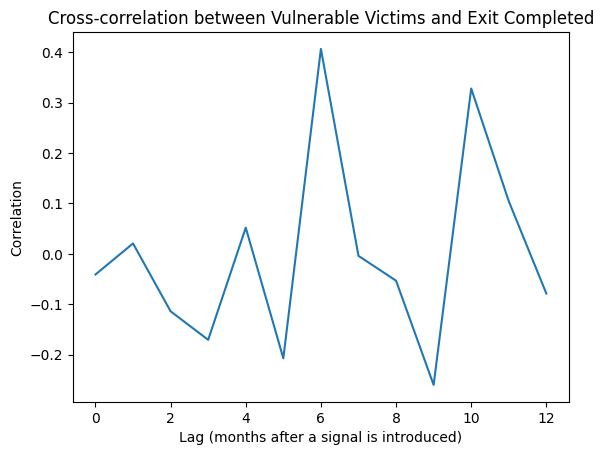

In [28]:
x = df['Abs. change on signal (Vulnerable Victims)'].fillna(0).values.flatten()
y = df['Abs. change on response (Exit Completed)'].fillna(0).values.flatten()
x = (x - x.mean()) / x.std()
y = (y - y.mean()) / y.std()
print(len(x), len(y))

corr = correlate(x, y, mode='full') / len(x)
lags = np.arange(-len(x)+1, len(x))
print(len(corr), len(lags))

# keep only causal lags: x leads y
mask = (lags <= 0) & (lags >= -12)
lags_causal = lags[mask]
corr_causal = corr[mask]
best_lag = lags_causal[np.argmax(corr_causal)]

print(f"\nBest lag: {best_lag} months with correlation {np.max(corr)}")
plt.plot(lags_causal * -1, corr_causal)
plt.title("Cross-correlation between Vulnerable Victims and Exit Completed")
plt.xlabel("Lag (months after a signal is introduced)")
plt.ylabel("Correlation")
plt.show()
# Interpretation: movements in signal tend to precede similar movements in response by approximately 6 months.

48 48
95 95

Best lag: -10 months with correlation 0.39522594949575374


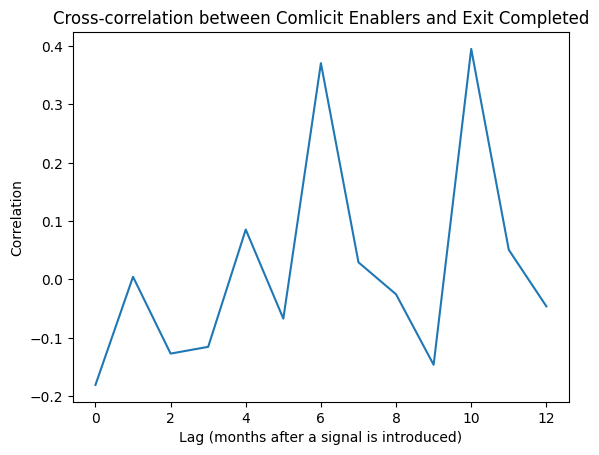

In [29]:
x = df['Abs. change on signal (Complicit Enablers)'].fillna(0).values.flatten()
y = df['Abs. change on response (Exit Completed)'].fillna(0).values.flatten()
x = (x - x.mean()) / x.std()
y = (y - y.mean()) / y.std()
print(len(x), len(y))

corr = correlate(x, y, mode='full') / len(x)
lags = np.arange(-len(x)+1, len(x))
print(len(corr), len(lags))

# keep only causal lags: x leads y
mask = (lags <= 0) & (lags >= -12)
lags_causal = lags[mask]
corr_causal = corr[mask]
best_lag = lags_causal[np.argmax(corr_causal)]

print(f"\nBest lag: {best_lag} months with correlation {np.max(corr)}")
plt.plot(lags_causal * -1, corr_causal)
plt.title("Cross-correlation between Comlicit Enablers and Exit Completed")
plt.xlabel("Lag (months after a signal is introduced)")
plt.ylabel("Correlation")
plt.show()

In [30]:
# Does Vulnerable Victims (signal) Granger-cause Exit Completed (response) (incremental predictive power)
d = df[["Abs. change on response (Exit Completed)", 
        "Abs. change on signal (Vulnerable Victims)"]].dropna()
gt = grangercausalitytests(d, maxlag=8)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0233  , p=0.8794  , df_denom=44, df_num=1
ssr based chi2 test:   chi2=0.0249  , p=0.8747  , df=1
likelihood ratio test: chi2=0.0249  , p=0.8747  , df=1
parameter F test:         F=0.0233  , p=0.8794  , df_denom=44, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.2767  , p=0.7597  , df_denom=41, df_num=2
ssr based chi2 test:   chi2=0.6210  , p=0.7331  , df=2
likelihood ratio test: chi2=0.6168  , p=0.7346  , df=2
parameter F test:         F=0.2767  , p=0.7597  , df_denom=41, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.9067  , p=0.4469  , df_denom=38, df_num=3
ssr based chi2 test:   chi2=3.2211  , p=0.3588  , df=3
likelihood ratio test: chi2=3.1111  , p=0.3748  , df=3
parameter F test:         F=0.9067  , p=0.4469  , df_denom=38, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=0.6184  , p=0.6523  , df_d

In [31]:
# Does Comlicit Enablers (signal) Granger-cause Exit Completed (response) (incremental predictive power)
d = df[["Abs. change on response (Exit Completed)", 
        "Abs. change on signal (Complicit Enablers)"]].dropna()
gt = grangercausalitytests(d, maxlag=8)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0096  , p=0.9224  , df_denom=44, df_num=1
ssr based chi2 test:   chi2=0.0102  , p=0.9194  , df=1
likelihood ratio test: chi2=0.0102  , p=0.9194  , df=1
parameter F test:         F=0.0096  , p=0.9224  , df_denom=44, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.3233  , p=0.7256  , df_denom=41, df_num=2
ssr based chi2 test:   chi2=0.7254  , p=0.6958  , df=2
likelihood ratio test: chi2=0.7197  , p=0.6978  , df=2
parameter F test:         F=0.3233  , p=0.7256  , df_denom=41, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.4993  , p=0.6850  , df_denom=38, df_num=3
ssr based chi2 test:   chi2=1.7738  , p=0.6207  , df=3
likelihood ratio test: chi2=1.7397  , p=0.6281  , df=3
parameter F test:         F=0.4993  , p=0.6850  , df_denom=38, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=0.3758  , p=0.8243  , df_d

In [32]:
# REVERSE
d = df[["Abs. change on signal (Vulnerable Victims)", 
        "Abs. change on response (Exit Completed)"]].dropna()
gt = grangercausalitytests(d, maxlag=6)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.2423  , p=0.6250  , df_denom=44, df_num=1
ssr based chi2 test:   chi2=0.2588  , p=0.6109  , df=1
likelihood ratio test: chi2=0.2581  , p=0.6114  , df=1
parameter F test:         F=0.2423  , p=0.6250  , df_denom=44, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.2037  , p=0.8166  , df_denom=41, df_num=2
ssr based chi2 test:   chi2=0.4570  , p=0.7957  , df=2
likelihood ratio test: chi2=0.4547  , p=0.7966  , df=2
parameter F test:         F=0.2037  , p=0.8166  , df_denom=41, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.7371  , p=0.5365  , df_denom=38, df_num=3
ssr based chi2 test:   chi2=2.6186  , p=0.4542  , df=3
likelihood ratio test: chi2=2.5452  , p=0.4672  , df=3
parameter F test:         F=0.7371  , p=0.5365  , df_denom=38, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=0.7114  , p=0.5897  , df_d

In [15]:
# REVERSE
d = df[["Abs. change on signal (Complicit Enablers)",
        "Abs. change on response (Exit Completed)"]].dropna()
gt = grangercausalitytests(d, maxlag=6)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.0460  , p=0.3120  , df_denom=44, df_num=1
ssr based chi2 test:   chi2=1.1173  , p=0.2905  , df=1
likelihood ratio test: chi2=1.1042  , p=0.2933  , df=1
parameter F test:         F=1.0460  , p=0.3120  , df_denom=44, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.5904  , p=0.5588  , df_denom=41, df_num=2
ssr based chi2 test:   chi2=1.3247  , p=0.5156  , df=2
likelihood ratio test: chi2=1.3060  , p=0.5205  , df=2
parameter F test:         F=0.5904  , p=0.5588  , df_denom=41, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.1752  , p=0.3319  , df_denom=38, df_num=3
ssr based chi2 test:   chi2=4.1750  , p=0.2432  , df=3
likelihood ratio test: chi2=3.9926  , p=0.2623  , df=3
parameter F test:         F=1.1752  , p=0.3319  , df_denom=38, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=1.2658  , p=0.3019  , df_d

In [ ]:
1. Goal

We will:

Use TimeSeriesSplit
Compare:
baseline model (Y lags only)
full model (Y + X lags)
Compute:
RMSE per fold
error differences
Compute a p-value (Wilcoxon test) across folds

In [16]:
import numpy as np
import pandas as pd

from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from scipy.stats import wilcoxon

In [18]:
df_model = df[[
    "Abs. change on response (Exit Completed)",
    "Abs. change on signal (Vulnerable Victims)"
]].dropna().copy()

In [513]:
df_model = df[["Abs. change on response (Exit Completed)",
               "Abs. change on signal (Complicit Enablers)",
        ]].dropna()

In [19]:
df_model.columns = ["y", "x"]

def make_lags(df, col, max_lag):
    out = pd.DataFrame(index=df.index)
    for lag in range(1, max_lag + 1):
        out[f"{col}_lag{lag}"] = df[col].shift(lag)
    return out

max_lag = 6

y_lags = make_lags(df_model, "y", max_lag)
x_lags = make_lags(df_model, "x", max_lag)

dataset = pd.concat([
    df_model["y"],
    y_lags,
    x_lags
], axis=1).dropna()

base_cols = [c for c in dataset.columns if c.startswith("y_lag")]
full_cols = base_cols + [c for c in dataset.columns if c.startswith("x_lag")]

tscv = TimeSeriesSplit(n_splits=5)

base_rmses = []
full_rmses = []

for train_idx, test_idx in tscv.split(dataset):

    train = dataset.iloc[train_idx]
    test  = dataset.iloc[test_idx]

    y_train = train["y"]
    y_test  = test["y"]

    # BASELINE
    Xb_train = train[base_cols]
    Xb_test  = test[base_cols]

    base_model = LinearRegression()
    base_model.fit(Xb_train, y_train)

    base_pred = base_model.predict(Xb_test)

    base_rmse = np.sqrt(mean_squared_error(y_test, base_pred))
    base_rmses.append(base_rmse)

    # FULL MODEL
    Xf_train = train[full_cols]
    Xf_test  = test[full_cols]

    full_model = LinearRegression()
    full_model.fit(Xf_train, y_train)

    full_pred = full_model.predict(Xf_test)

    full_rmse = np.sqrt(mean_squared_error(y_test, full_pred))
    full_rmses.append(full_rmse)

base_rmses = np.array(base_rmses)
full_rmses = np.array(full_rmses)

print("Lag:", max_lag)

print("Baseline RMSEs:", base_rmses)
print("Full RMSEs:", full_rmses)

print("\nBaseline RMSE avg:", base_rmses.mean())
print("Full RMSE avg:", full_rmses.mean())

improvement = base_rmses.mean() - full_rmses.mean()

print("Improvement:", improvement)

diff = base_rmses - full_rmses

stat, p_value = wilcoxon(diff)

print("Wilcoxon statistic:", stat)
print("p-value:", p_value)
#Full RMSE << Baseline RMSE
#→ X has real predictive power for Y
#→ your Granger signal is validated

Lag: 6
Baseline RMSEs: [30.33991764  1.45111549  1.06390182  0.7485202   0.60465267]
Full RMSEs: [5.44112653 2.16905746 1.11521078 1.55787342 0.98438125]

Baseline RMSE avg: 6.84162156624633
Full RMSE avg: 2.2535298864216964
Improvement: 4.588091679824633
Wilcoxon statistic: 5.0
p-value: 0.625


In [319]:
window = 24   # e.g. 24 months
maxlag = 6
step = 1
data = df[["Abs. change on response (Exit Completed)", 
        "Abs. change on signal (Complicit Enablers)"]].dropna()
results = []

In [320]:
for start in range(0, len(data) - window + 1, step):
    end = start + window
    chunk = data.iloc[start:end]

    try:
        test = grangercausalitytests(chunk, maxlag=maxlag, verbose=False)

        # extract p-values for each lag (F-test)
        pvals = [test[lag][0]["ssr_ftest"][1] for lag in range(1, maxlag+1)]

        results.append({
            "start": chunk.index[0],
            "end": chunk.index[-1],
            "min_p": min(pvals),   # strongest evidence in window
            "best_lag": np.argmin(pvals) + 1
        })

    except Exception:
        continue

c:\chru\.venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


In [321]:
roll_df = pd.DataFrame(results)

In [322]:
roll_df 

,start,end,min_p,best_lag
0,2022-01-31,2023-12-31,0.198864,5
1,2022-02-28,2024-01-31,0.175158,5
2,2022-03-31,2024-02-29,0.253793,5
3,2022-04-30,2024-03-31,0.236432,5
4,2022-05-31,2024-04-30,0.091443,4
5,2022-06-30,2024-05-31,0.042951,1
6,2022-07-31,2024-06-30,0.053111,1
7,2022-08-31,2024-07-31,0.048280,1
8,2022-09-30,2024-08-31,0.069703,1
9,2022-10-31,2024-09-30,0.058722,1


In [323]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [324]:
def make_lags(df, col, max_lag):
    out = pd.DataFrame(index=df.index)
    for lag in range(1, max_lag + 1):
        out[f"{col}_lag{lag}"] = df[col].shift(lag)
    return out

In [355]:
df_model = df[[
    "Abs. change on response (Exit Completed)",
    "Abs. change on signal (Complicit Enablers)"
]].dropna().copy()

df_model.columns = ["y", "x"]

max_lag = 6

y_lags = make_lags(df_model, "y", max_lag)
x_lags = make_lags(df_model, "x", max_lag)

X_base = y_lags
X_full = pd.concat([y_lags, x_lags], axis=1)

y = df_model["y"]

data_base = pd.concat([y, X_base], axis=1).dropna()
data_full = pd.concat([y, X_full], axis=1).dropna()

y_base = data_base["y"]
X_base = data_base.drop(columns=["y"])

y_full = data_full["y"]
X_full = data_full.drop(columns=["y"])

split_base = int(len(data_base) * 0.7)
split_full = int(len(data_full) * 0.7)

Xb_train, Xb_test = X_base.iloc[:split_base], X_base.iloc[split_base:]
yb_train, yb_test = y_base.iloc[:split_base], y_base.iloc[split_base:]

Xf_train, Xf_test = X_full.iloc[:split_full], X_full.iloc[split_full:]
yf_train, yf_test = y_full.iloc[:split_full], y_full.iloc[split_full:]

base_model = LinearRegression()
base_model.fit(Xb_train, yb_train)

full_model = LinearRegression()
full_model.fit(Xf_train, yf_train)

base_pred = base_model.predict(Xb_test)
full_pred = full_model.predict(Xf_test)

base_rmse = np.sqrt(mean_squared_error(yb_test, base_pred))
full_rmse = np.sqrt(mean_squared_error(yf_test, full_pred))

print("Baseline RMSE:", base_rmse)
print("Full model RMSE:", full_rmse)
print("Improvement:", base_rmse - full_rmse)
#Full RMSE << Baseline RMSE
#→ X has real predictive power for Y
#→ your Granger signal is validated

import numpy as np
from scipy import stats

# errors
e_base = yb_test - base_pred
e_full = yf_test - full_pred

# align lengths (important if indices differ slightly)
min_len = min(len(e_base), len(e_full))

e_base = np.array(e_base[-min_len:])
e_full = np.array(e_full[-min_len:])

# squared errors
se_base = e_base**2
se_full = e_full**2

# loss differential
d = se_base - se_full

t_stat, p_value = stats.ttest_1samp(d, 0)

print("t-stat:", t_stat)
print("p-value:", p_value)

Baseline RMSE: 0.6892852397471834
Full model RMSE: 0.6082721848749828
Improvement: 0.08101305487220056
t-stat: 0.7926527715843135
p-value: 0.44336949278260496


In [354]:
df_model = df[[
    "Abs. change on response (Exit Completed)",
    "Abs. change on signal (Vulnerable Victims)"
]].dropna().copy()

df_model.columns = ["y", "x"]

max_lag = 6

y_lags = make_lags(df_model, "y", max_lag)
x_lags = make_lags(df_model, "x", max_lag)

X_base = y_lags
X_full = pd.concat([y_lags, x_lags], axis=1)

y = df_model["y"]

data_base = pd.concat([y, X_base], axis=1).dropna()
data_full = pd.concat([y, X_full], axis=1).dropna()

y_base = data_base["y"]
X_base = data_base.drop(columns=["y"])

y_full = data_full["y"]
X_full = data_full.drop(columns=["y"])

split_base = int(len(data_base) * 0.7)
split_full = int(len(data_full) * 0.7)

Xb_train, Xb_test = X_base.iloc[:split_base], X_base.iloc[split_base:]
yb_train, yb_test = y_base.iloc[:split_base], y_base.iloc[split_base:]

Xf_train, Xf_test = X_full.iloc[:split_full], X_full.iloc[split_full:]
yf_train, yf_test = y_full.iloc[:split_full], y_full.iloc[split_full:]

base_model = LinearRegression()
base_model.fit(Xb_train, yb_train)

full_model = LinearRegression()
full_model.fit(Xf_train, yf_train)

base_pred = base_model.predict(Xb_test)
full_pred = full_model.predict(Xf_test)

base_rmse = np.sqrt(mean_squared_error(yb_test, base_pred))
full_rmse = np.sqrt(mean_squared_error(yf_test, full_pred))

print("Baseline RMSE:", base_rmse)
print("Full model RMSE:", full_rmse)
print("Improvement:", base_rmse - full_rmse)
#Full RMSE << Baseline RMSE
#→ X has real predictive power for Y
#→ your Granger signal is validated

import numpy as np
from scipy import stats

# errors
e_base = yb_test - base_pred
e_full = yf_test - full_pred

# align lengths (important if indices differ slightly)
min_len = min(len(e_base), len(e_full))

e_base = np.array(e_base[-min_len:])
e_full = np.array(e_full[-min_len:])

# squared errors
se_base = e_base**2
se_full = e_full**2

# loss differential
d = se_base - se_full

t_stat, p_value = stats.ttest_1samp(d, 0)

print("t-stat:", t_stat)
print("p-value:", p_value)

Baseline RMSE: 0.6892852397471834
Full model RMSE: 0.45159148175142916
Improvement: 0.2376937579957542
t-stat: 2.749294791785264
p-value: 0.017625288646314567


t-stat: 1.0907083332021947
p-value: 0.29681803037358845


In [ ]:
df_vv = pd.read_csv("./results/full_agreement_code_vulnerable_victims.csv")
for m in models:
    if m in df_vv.columns:
        f = pd.to_numeric(df_vv[m]) > 0
        print(f"{m:<14}: {f.sum():.0f} ~ {f.sum() / len(f) * 100:.1f}%")
a = df_vv['code_applied'] > 0
b = df_vv['w_code_applied'] > 0
print("-" * 40)
print(f"{'agreement':<14}: {a.sum():.0f} ~ {a.sum() / len(a) * 100:.1f}%")
print(f"{'w. agreement':<14}: {b.sum():.0f} ~ {b.sum() / len(b) * 100:.1f}%")
df_vv['vulnerable_victims'] = df_vv['code_applied']

df_ce = pd.read_csv("./results/full_agreement_code_complicit_enablers.csv")
for m in models:
    if m in df_ce.columns:
        f = pd.to_numeric(df_ce[m]) > 0
        print(f"{m:<14}: {f.sum():.0f} ~ {f.sum() / len(f) * 100:.1f}%")
a = df_ce['code_applied'] > 0
b = df_ce['w_code_applied'] > 0
print("-" * 40)
print(f"{'agreement':<14}: {a.sum():.0f} ~ {a.sum() / len(a) * 100:.1f}%")
print(f"{'w. agreement':<14}: {b.sum():.0f} ~ {b.sum() / len(b) * 100:.1f}%")
df_ce['complicit_enablers'] = df_ce['code_applied']

In [77]:
df

,Company name,Industry,Description of operations identified,2024-03-17 00:00:00,2024-03-24 00:00:00,2024-03-31 00:00:00,2024-04-07 00:00:00,2024-04-14 00:00:00,2024-04-21 00:00:00,2024-04-28 00:00:00,...,2025-03-31 00:00:00,2025-04-30 00:00:00,2025-05-31 00:00:00,2025-06-30 00:00:00,2025-07-31 00:00:00,2025-08-31 00:00:00,2025-09-30 00:00:00,2025-10-31 00:00:00,2025-11-30 00:00:00,2025-12-31 00:00:00
5,ABB,"Energy, oil and gas",NaN,,SCALING BACK,SCALING BACK,SCALING BACK,SCALING BACK,SCALING BACK,SCALING BACK,...,SUSPENSION,SUSPENSION,WITHDRAWAL,WITHDRAWAL,WITHDRAWAL,WITHDRAWAL,WITHDRAWAL,WITHDRAWAL,WITHDRAWAL,EXIT COMPLETED
15,Acronis,IT,suspend operations in Russia,WITHDRAWAL,WITHDRAWAL,WITHDRAWAL,WITHDRAWAL,WITHDRAWAL,WITHDRAWAL,WITHDRAWAL,...,WITHDRAWAL,WITHDRAWAL,WITHDRAWAL,WITHDRAWAL,WITHDRAWAL,WITHDRAWAL,WITHDRAWAL,WITHDRAWAL,WITHDRAWAL,WITHDRAWAL
54,AMCOR,Consumer goods and clothing,NaN,,,,,SCALING BACK,SCALING BACK,SCALING BACK,...,EXIT COMPLETED,EXIT COMPLETED,EXIT COMPLETED,EXIT COMPLETED,EXIT COMPLETED,EXIT COMPLETED,EXIT COMPLETED,EXIT COMPLETED,EXIT COMPLETED,EXIT COMPLETED
114,Barry Callebaut,Food&Beverages,Continuing production in Russia with its 3 fac...,,,,,BUYING TIME,BUYING TIME,BUYING TIME,...,DIGGING IN,DIGGING IN,DIGGING IN,DIGGING IN,DIGGING IN,DIGGING IN,DIGGING IN,DIGGING IN,DIGGING IN,DIGGING IN
160,Burckhardt Compression AG,Industrial equipment,not to accept any new orders from or for Russi...,SUSPENSION,SUSPENSION,SUSPENSION,SUSPENSION,SUSPENSION,SUSPENSION,SUSPENSION,...,SUSPENSION,SUSPENSION,SUSPENSION,SUSPENSION,SUSPENSION,SUSPENSION,SUSPENSION,SUSPENSION,SUSPENSION,SUSPENSION
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4006,AnaPico,Electronics,"Analyzing customs data, The Insider found out ...",,,,,,,,...,WITHDRAWAL,WITHDRAWAL,WITHDRAWAL,WITHDRAWAL,WITHDRAWAL,WITHDRAWAL,WITHDRAWAL,WITHDRAWAL,WITHDRAWAL,WITHDRAWAL
4132,Datamars,Agriculture,"Datamars supplies ear tags for cattle, microch...",,,,,,,,...,SCALING BACK,SCALING BACK,SCALING BACK,SCALING BACK,SCALING BACK,SCALING BACK,SCALING BACK,SCALING BACK,SCALING BACK,SCALING BACK
4148,Sierentz Global Merchants,Agriculture,Steppe Agroholding acquired full control of RZ...,,,,,,,,...,EXIT COMPLETED,EXIT COMPLETED,EXIT COMPLETED,EXIT COMPLETED,EXIT COMPLETED,EXIT COMPLETED,EXIT COMPLETED,EXIT COMPLETED,EXIT COMPLETED,EXIT COMPLETED
4252,International Bobsleigh & Skeleton Federation ...,Sport,The International Bobsleigh & Skeleton Federat...,,,,,,,,...,,,,,,,SUSPENSION,SUSPENSION,SCALING BACK,SCALING BACK


In [80]:
statuses = pd.concat([df[c] for c in decision_cols], axis=0, ignore_index=True)
statuses.str.replace(" – ", " - ")\
    .str.upper().fillna('')\
    .str.replace("!TO BE VERIFIED", "")\
        .apply(lambda x: x.split(" - ")[0]).value_counts()

                  2394
SUSPENSION        1958
DIGGING IN        1391
WITHDRAWAL        1182
REMAIN IN RF      1123
SCALING BACK       946
EXIT COMPLETED     664
BUYING TIME        376
Name: count, dtype: int64

In [ ]:
statuses.v

SUSPENSION – Keeping Options Open for Return                              563
WITHDRAWAL - Clean Break - Surgical Removal, Resection                    401
Remain in RF                                                              277
SCALING BACK – Reducing Current Operations                                248
BUYING TIME – Holding Off New Investments/Development                     178
DIGGING IN – Defying Demands for Exit or Reduction of Activities          168
EXIT COMPLETED - Company sold its business/assets                          37
!To be verified                                                            33
SCALING BACK – Reducing Current Operations/Holding Off New Investments      7
Name: count, dtype: int64

['Company name',
 'Industry',
 'Description of operations identified',
 'Status of decision 17/03',
 'Status of decision 24/03',
 'Status of decision 31/03',
 'Status of decision 07/04',
 'Status of decision 14/04',
 'Status of decision 21/04',
 'Status of decision 28/04',
 'Status of decision 05/05',
 'Status of decision 12/05',
 'Status of decision 19/05',
 'Status of decision 29/05',
 'Status of decision 02/06',
 'Status of decision 09/06',
 'Status of decision 16/06',
 'Status of decision 23/06',
 'Status of decision 30/06',
 'Status of decision 01-31/07',
 'Status of decision 01-31/08',
 'Status of decision 01-30/09',
 'Status of decision 01-31/10',
 'Status of decision 01-30/11',
 'Status of decision 01-31/12']

In [ ]:
df_vv = pd.read_csv("./results/full_agreement_code_vulnerable_victims.csv")
for m in models:
    if m in df_vv.columns:
        f = pd.to_numeric(df_vv[m]) > 0
        print(f"{m:<14}: {f.sum():.0f} ~ {f.sum() / len(f) * 100:.1f}%")
a = df_vv['code_applied'] > 0
b = df_vv['w_code_applied'] > 0
print("-" * 40)
print(f"{'agreement':<14}: {a.sum():.0f} ~ {a.sum() / len(a) * 100:.1f}%")
print(f"{'w. agreement':<14}: {b.sum():.0f} ~ {b.sum() / len(b) * 100:.1f}%")
df_vv['vulnerable_victims'] = df_vv['code_applied']

df_ce = pd.read_csv("./results/full_agreement_code_complicit_enablers.csv")
for m in models:
    if m in df_ce.columns:
        f = pd.to_numeric(df_ce[m]) > 0
        print(f"{m:<14}: {f.sum():.0f} ~ {f.sum() / len(f) * 100:.1f}%")
a = df_ce['code_applied'] > 0
b = df_ce['w_code_applied'] > 0
print("-" * 40)
print(f"{'agreement':<14}: {a.sum():.0f} ~ {a.sum() / len(a) * 100:.1f}%")
print(f"{'w. agreement':<14}: {b.sum():.0f} ~ {b.sum() / len(b) * 100:.1f}%")
df_ce['complicit_enablers'] = df_ce['code_applied']

llama3.3:70b  : 131 ~ 1.7%
gpt-oss:120b  : 134 ~ 1.8%
deepseek-r1:70b: 223 ~ 2.9%
qwen2.5:72b   : 50 ~ 0.7%
----------------------------------------
agreement     : 52 ~ 0.7%
w. agreement  : 52 ~ 0.7%


llama3.3:70b  : 263 ~ 3.4%
gpt-oss:120b  : 241 ~ 3.2%
deepseek-r1:70b: 272 ~ 3.6%
qwen2.5:72b   : 94 ~ 1.2%
----------------------------------------
agreement     : 133 ~ 1.7%
w. agreement  : 133 ~ 1.7%


In [58]:
df = pd.merge(df_vv, df_ce, on="hash", how="left")
df['both'] = df.apply(lambda x: 1 if x['vulnerable_victims'] > 0 and x['complicit_enablers'] > 0 else 0, axis=1)
print(f"Both codes applied: {df['both'].sum()} ~ {df['both'].sum() / len(df) * 100:.1f}%")

Both codes applied: 2 ~ 0.0%


In [55]:
df[df['both'] == 1].text_raw_y

1650    FINWIR0020220424ei4n0001n Schweiz Der Genfer Ö...
3907    JAHREV0020221124eibn00098 Wirtschaft Swiss Kro...
Name: text_raw_y, dtype: object

In [37]:
df_as = pd.read_csv("./results/full_agreement_code_adapted_sovereignty.csv", parse_dates=["datetime"])
for m in models:
    if m in df_as.columns:
        f = pd.to_numeric(df_as[m]) > 0
        print(f"{m:<14}: {f.sum():.0f} ~ {f.sum() / len(f) * 100:.1f}%")
a = df_as['code_applied'] > 0
b = df_as['w_code_applied'] > 0
print("-" * 40)
print(f"{'agreement':<14}: {a.sum():.0f} ~ {a.sum() / len(a) * 100:.1f}%")
print(f"{'w. agreement':<14}: {b.sum():.0f} ~ {b.sum() / len(b) * 100:.1f}%")
df_as['adapted_sovereignty'] = df_as['code_applied']

llama3.3:70b  : 2811 ~ 52.6%
gpt-oss:120b  : 1872 ~ 35.0%
deepseek-r1:70b: 2448 ~ 45.8%
qwen2.5:72b   : 2546 ~ 47.6%
----------------------------------------
agreement     : 2145 ~ 40.1%
w. agreement  : 2145 ~ 40.1%


In [38]:
df_cl = pd.read_csv("./results/full_agreement_code_conditional_loyalty.csv", parse_dates=["datetime"])
for m in models:
    if m in df_cl.columns:
        f = pd.to_numeric(df_cl[m]) > 0
        print(f"{m:<14}: {f.sum():.0f} ~ {f.sum() / len(f) * 100:.1f}%")
a = df_cl['code_applied'] > 0
b = df_cl['w_code_applied'] > 0
print("-" * 40)
print(f"{'agreement':<14}: {a.sum():.0f} ~ {a.sum() / len(a) * 100:.1f}%")
print(f"{'w. agreement':<14}: {b.sum():.0f} ~ {b.sum() / len(b) * 100:.1f}%")
df_cl['conditional_loyalty'] = df_cl['code_applied']

llama3.3:70b  : 1125 ~ 21.1%
gpt-oss:120b  : 716 ~ 13.4%
deepseek-r1:70b: 1292 ~ 24.2%
qwen2.5:72b   : 1864 ~ 34.9%
----------------------------------------
agreement     : 893 ~ 16.7%
w. agreement  : 535 ~ 10.0%


Both codes applied: 469 ~ 8.8%


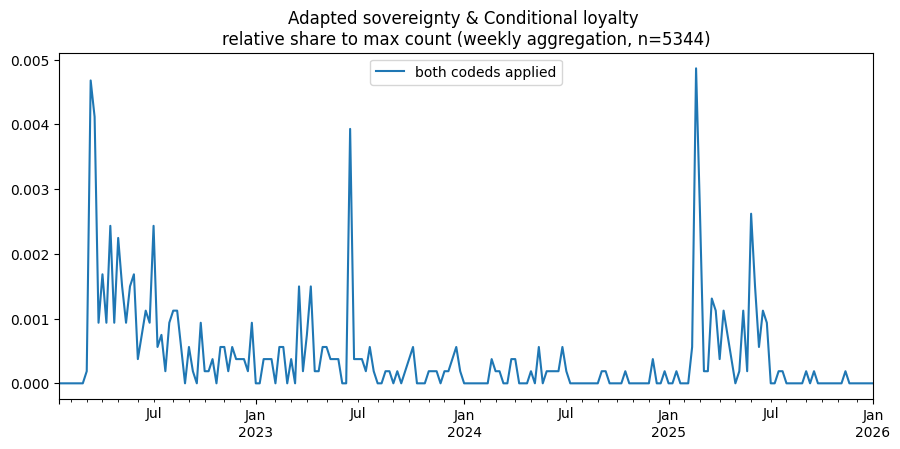

In [43]:
df = pd.merge(df_as, df_cl, on=["hash", "datetime"], how="left")
df['both_code_applied'] = df.apply(lambda x: 1 if x['adapted_sovereignty'] > 0 and x['conditional_loyalty'] > 0 else 0, axis=1)
print(f"Both codes applied: {df['both_code_applied'].sum()} ~ {df['both_code_applied'].sum() / len(df) * 100:.1f}%")
fig = plt.figure(figsize=(10.5, 4.5))
ax = fig.add_subplot()
df['count'] = 1
df = df.copy().set_index('datetime').resample("1W").sum()
(df['both_code_applied'] / df['count'].sum()).plot(ax=ax, label='both codeds applied')
ax.set_title(f"Adapted sovereignty & Conditional loyalty \nrelative share to max count (weekly aggregation, n={df['count'].sum()})")
ax.set_xlabel(None)
ax.legend()

In [3]:
df = pd.read_csv("./results/full_agreement_code_vulnerable_victims.csv")
for m in models:
    if m in df.columns:
        f = pd.to_numeric(df[m]) > 0
        print(f"{m:<14}: {f.sum():.0f} ~ {f.sum() / len(f) * 100:.1f}%")
a = df['code_applied'] > 0
b = df['w_code_applied'] > 0
print("-" * 40)
print(f"{'agreement':<14}: {a.sum():.0f} ~ {a.sum() / len(a) * 100:.1f}%")
print(f"{'w. agreement':<14}: {b.sum():.0f} ~ {b.sum() / len(b) * 100:.1f}%")

llama3.3:70b  : 131 ~ 1.7%
gpt-oss:120b  : 134 ~ 1.8%
deepseek-r1:70b: 223 ~ 2.9%
qwen2.5:72b   : 50 ~ 0.7%
----------------------------------------
agreement     : 52 ~ 0.7%
w. agreement  : 52 ~ 0.7%


In [4]:
df = pd.read_csv("./results/full_agreement_code_complicit_enablers.csv")
for m in models:
    if m in df.columns:
        f = pd.to_numeric(df[m]) > 0
        print(f"{m:<14}: {f.sum():.0f} ~ {f.sum() / len(f) * 100:.1f}%")
a = df['code_applied'] > 0
b = df['w_code_applied'] > 0
print("-" * 40)
print(f"{'agreement':<14}: {a.sum():.0f} ~ {a.sum() / len(a) * 100:.1f}%")
print(f"{'w. agreement':<14}: {b.sum():.0f} ~ {b.sum() / len(b) * 100:.1f}%")

llama3.3:70b  : 263 ~ 3.4%
gpt-oss:120b  : 241 ~ 3.2%
deepseek-r1:70b: 272 ~ 3.6%
qwen2.5:72b   : 94 ~ 1.2%
----------------------------------------
agreement     : 133 ~ 1.7%
w. agreement  : 133 ~ 1.7%


In [5]:
df = pd.read_csv("./results/full_agreement_code_adapted_sovereignty.csv")
for m in models:
    if m in df.columns:
        f = pd.to_numeric(df[m]) > 0
        print(f"{m:<14}: {f.sum():.0f} ~ {f.sum() / len(f) * 100:.1f}%")
a = df['code_applied'] > 0
b = df['w_code_applied'] > 0
print("-" * 40)
print(f"{'agreement':<14}: {a.sum():.0f} ~ {a.sum() / len(a) * 100:.1f}%")
print(f"{'w. agreement':<14}: {b.sum():.0f} ~ {b.sum() / len(b) * 100:.1f}%")

llama3.3:70b  : 2811 ~ 52.6%
gpt-oss:120b  : 1872 ~ 35.0%
deepseek-r1:70b: 2448 ~ 45.8%
qwen2.5:72b   : 2546 ~ 47.6%
----------------------------------------
agreement     : 2145 ~ 40.1%
w. agreement  : 2145 ~ 40.1%


In [7]:
df = pd.read_csv("./results/full_agreement_code_conditional_loyalty.csv")
for m in models:
    if m in df.columns:
        f = pd.to_numeric(df[m]) > 0
        print(f"{m:<14}: {f.sum():.0f} ~ {f.sum() / len(f) * 100:.1f}%")
a = df['code_applied'] > 0
b = df['w_code_applied'] > 0
print("-" * 40)
print(f"{'agreement':<14}: {a.sum():.0f} ~ {a.sum() / len(a) * 100:.1f}%")
print(f"{'w. agreement':<14}: {b.sum():.0f} ~ {b.sum() / len(b) * 100:.1f}%")

llama3.3:70b  : 1125 ~ 21.1%
gpt-oss:120b  : 716 ~ 13.4%
deepseek-r1:70b: 1292 ~ 24.2%
qwen2.5:72b   : 1864 ~ 34.9%
----------------------------------------
agreement     : 893 ~ 16.7%
w. agreement  : 535 ~ 10.0%


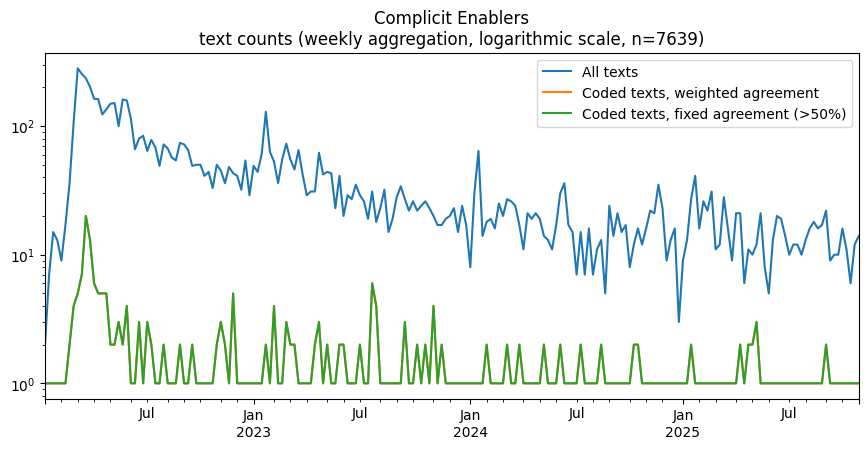

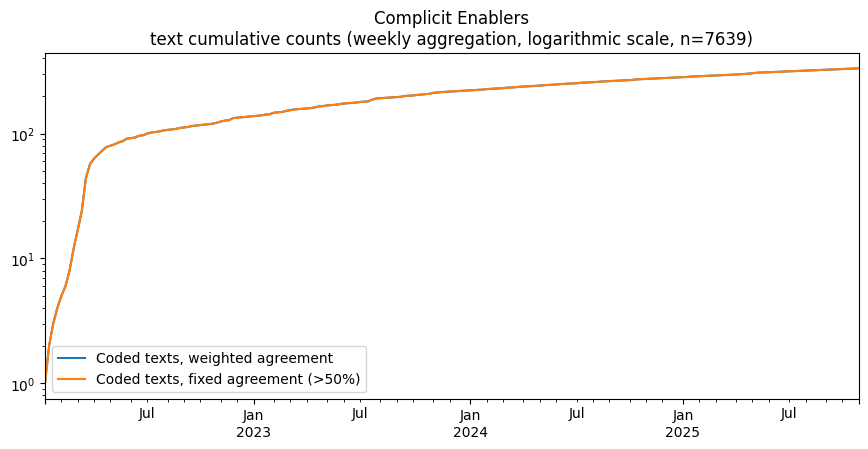

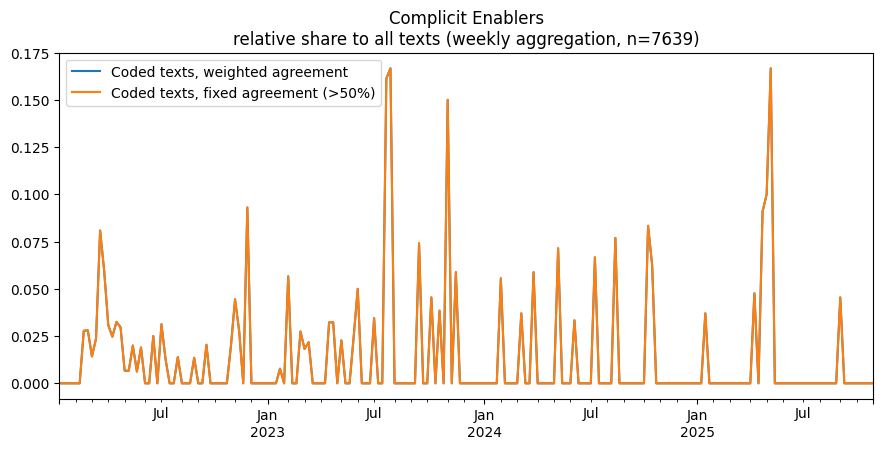

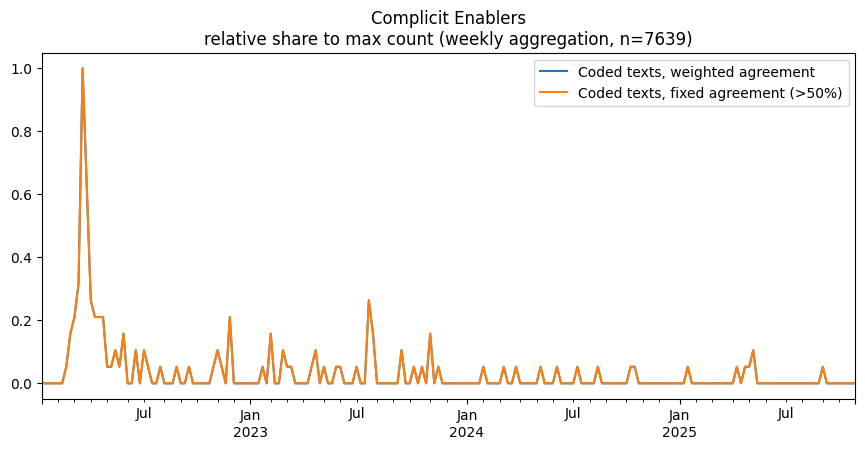

In [8]:
fig = plt.figure(figsize=(10.5, 4.5))
ax = fig.add_subplot()
df = pd.read_csv("./results/full_agreement_code_complicit_enablers.csv", parse_dates=["datetime"])
df['count'] = 1
df = df.copy().set_index('datetime').resample("1W").sum()
df['count'].plot(ax=ax, label='All texts')
(df['w_code_applied']+1).plot(ax=ax, label='Coded texts, weighted agreement')
(df['code_applied']+1).plot(ax=ax, label='Coded texts, fixed agreement (>50%)')
ax.set_title(f"Complicit Enablers\ntext counts (weekly aggregation, logarithmic scale, n={df['count'].sum()})")
ax.set_xlabel(None)
ax.set_yscale('log')
ax.legend()

fig = plt.figure(figsize=(10.5, 4.5))
ax = fig.add_subplot()
df = pd.read_csv("./results/full_agreement_code_complicit_enablers.csv", parse_dates=["datetime"])
df['count'] = 1
df = df.copy().set_index('datetime').resample("1W").sum()
#df['count'].cumsum().plot(ax=ax, label='All texts')
(df['w_code_applied']+1).cumsum().plot(ax=ax, label='Coded texts, weighted agreement')
(df['code_applied']+1).cumsum().plot(ax=ax, label='Coded texts, fixed agreement (>50%)')
ax.set_title(f"Complicit Enablers\ntext cumulative counts (weekly aggregation, logarithmic scale, n={df['count'].sum()})")
ax.set_xlabel(None)
ax.set_yscale('log')
ax.legend()

fig = plt.figure(figsize=(10.5, 4.5))
ax = fig.add_subplot()
df = pd.read_csv("./results/full_agreement_code_complicit_enablers.csv", parse_dates=["datetime"])
df['count'] = 1
df = df.copy().set_index('datetime').resample("1W").sum()
(df['w_code_applied'] / df['count']).plot(ax=ax, label='Coded texts, weighted agreement')
(df['code_applied'] / df['count']).plot(ax=ax, label='Coded texts, fixed agreement (>50%)')
ax.set_title(f"Complicit Enablers\nrelative share to all texts (weekly aggregation, n={df['count'].sum()})")
ax.set_xlabel(None)
ax.legend()

fig = plt.figure(figsize=(10.5, 4.5))
ax = fig.add_subplot()
df = pd.read_csv("./results/full_agreement_code_complicit_enablers.csv", parse_dates=["datetime"])
df['count'] = 1
df = df.copy().set_index('datetime').resample("1W").sum()
(df['w_code_applied'] / df['w_code_applied'].max()).plot(ax=ax, label='Coded texts, weighted agreement')
(df['code_applied'] / df['code_applied'].max()).plot(ax=ax, label='Coded texts, fixed agreement (>50%)')
ax.set_title(f"Complicit Enablers\nrelative share to max count (weekly aggregation, n={df['count'].sum()})")
ax.set_xlabel(None)
ax.legend()

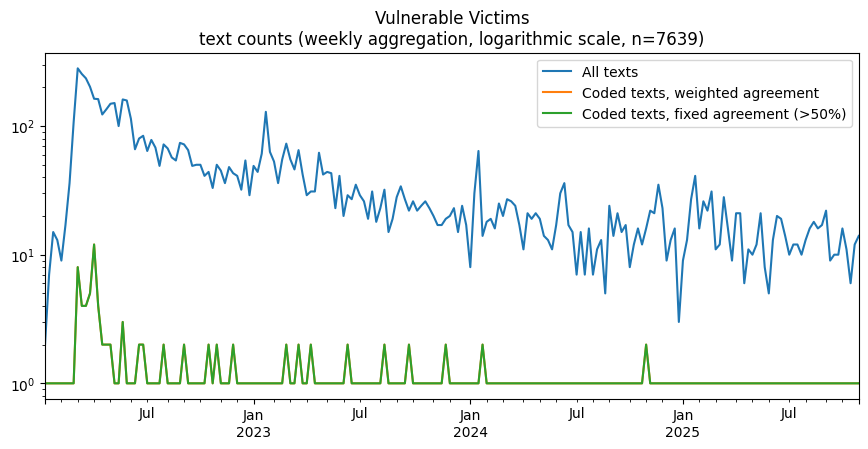

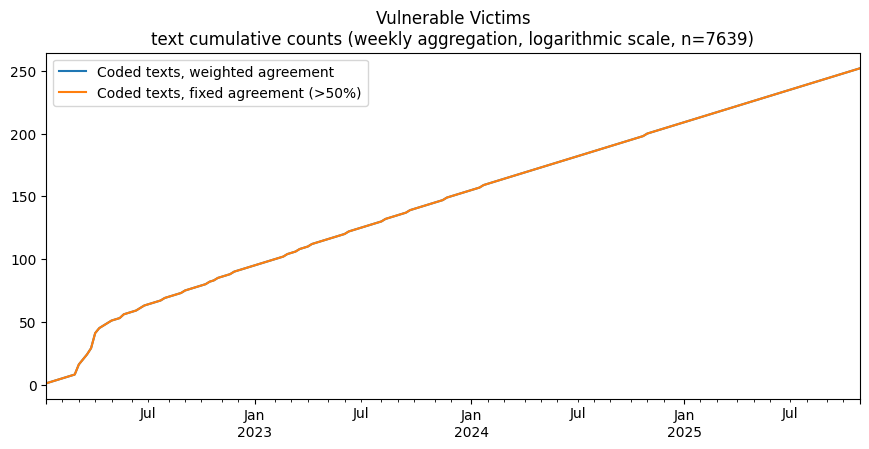

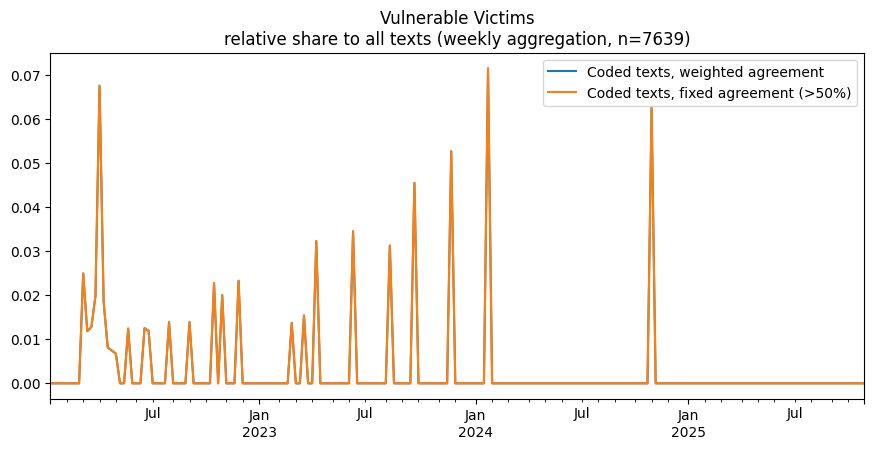

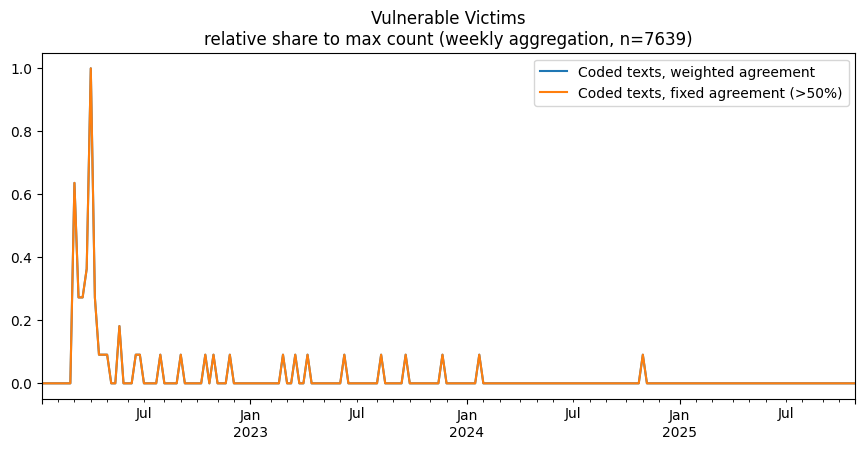

In [9]:
fig = plt.figure(figsize=(10.5, 4.5))
ax = fig.add_subplot()
df = pd.read_csv("./results/full_agreement_code_vulnerable_victims.csv", parse_dates=["datetime"])
df['count'] = 1
df = df.copy().set_index('datetime').resample("1W").sum()
df['count'].plot(ax=ax, label='All texts')
(df['w_code_applied']+1).plot(ax=ax, label='Coded texts, weighted agreement')
(df['code_applied']+1).plot(ax=ax, label='Coded texts, fixed agreement (>50%)')
ax.set_title(f"Vulnerable Victims\ntext counts (weekly aggregation, logarithmic scale, n={df['count'].sum()})")
ax.set_xlabel(None)
ax.set_yscale('log')
ax.legend()

fig = plt.figure(figsize=(10.5, 4.5))
ax = fig.add_subplot()
df = pd.read_csv("./results/full_agreement_code_vulnerable_victims.csv", parse_dates=["datetime"])
df['count'] = 1
df = df.copy().set_index('datetime').resample("1W").sum()
#df['count'].cumsum().plot(ax=ax, label='All texts')
(df['w_code_applied']+1).cumsum().plot(ax=ax, label='Coded texts, weighted agreement')
(df['code_applied']+1).cumsum().plot(ax=ax, label='Coded texts, fixed agreement (>50%)')
ax.set_title(f"Vulnerable Victims\ntext cumulative counts (weekly aggregation, logarithmic scale, n={df['count'].sum()})")
ax.set_xlabel(None)
#ax.set_yscale('log')
ax.legend()


fig = plt.figure(figsize=(10.5, 4.5))
ax = fig.add_subplot()
df = pd.read_csv("./results/full_agreement_code_vulnerable_victims.csv", parse_dates=["datetime"])
df['count'] = 1
df = df.copy().set_index('datetime').resample("1W").sum()
(df['w_code_applied'] / df['count']).plot(ax=ax, label='Coded texts, weighted agreement')
(df['code_applied'] / df['count']).plot(ax=ax, label='Coded texts, fixed agreement (>50%)')
ax.set_title(f"Vulnerable Victims\nrelative share to all texts (weekly aggregation, n={df['count'].sum()})")
ax.set_xlabel(None)
ax.legend()

fig = plt.figure(figsize=(10.5, 4.5))
ax = fig.add_subplot()
df = pd.read_csv("./results/full_agreement_code_vulnerable_victims.csv", parse_dates=["datetime"])
df['count'] = 1
df = df.copy().set_index('datetime').resample("1W").sum()
(df['w_code_applied'] / df['w_code_applied'].max()).plot(ax=ax, label='Coded texts, weighted agreement')
(df['code_applied'] / df['code_applied'].max()).plot(ax=ax, label='Coded texts, fixed agreement (>50%)')
ax.set_title(f"Vulnerable Victims\nrelative share to max count (weekly aggregation, n={df['count'].sum()})")
ax.set_xlabel(None)
ax.legend()

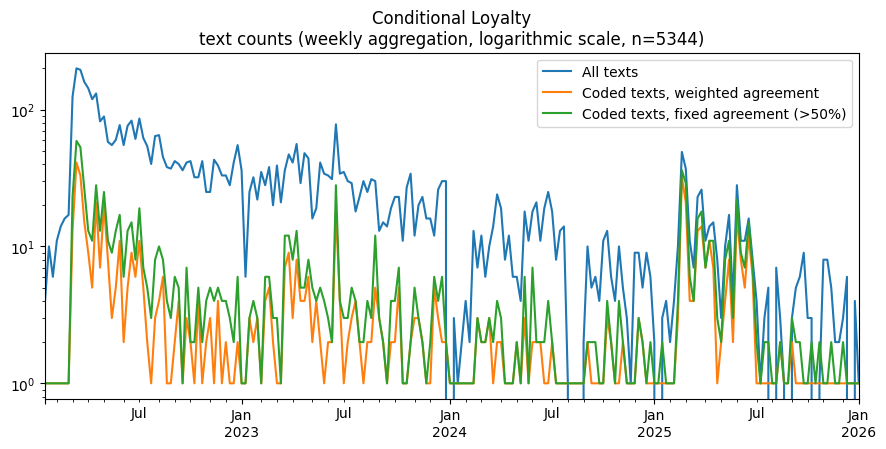

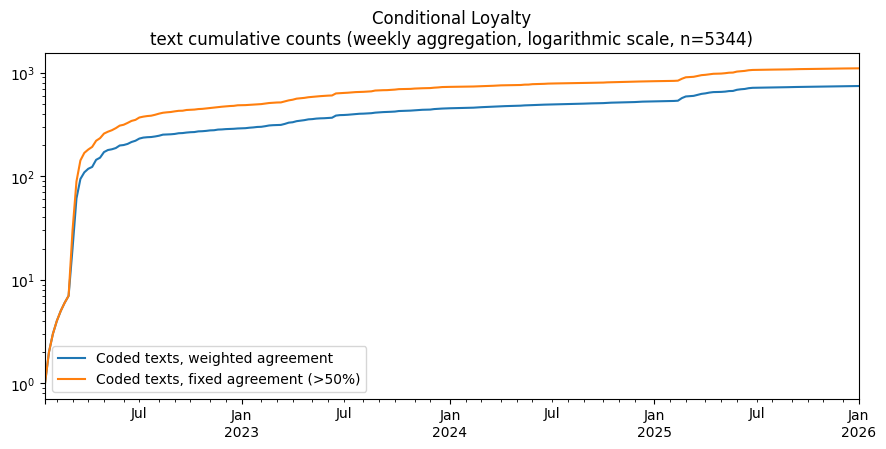

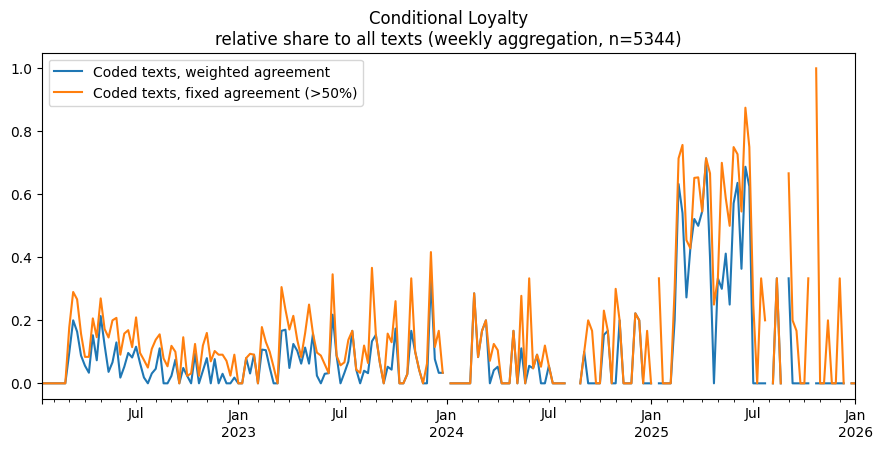

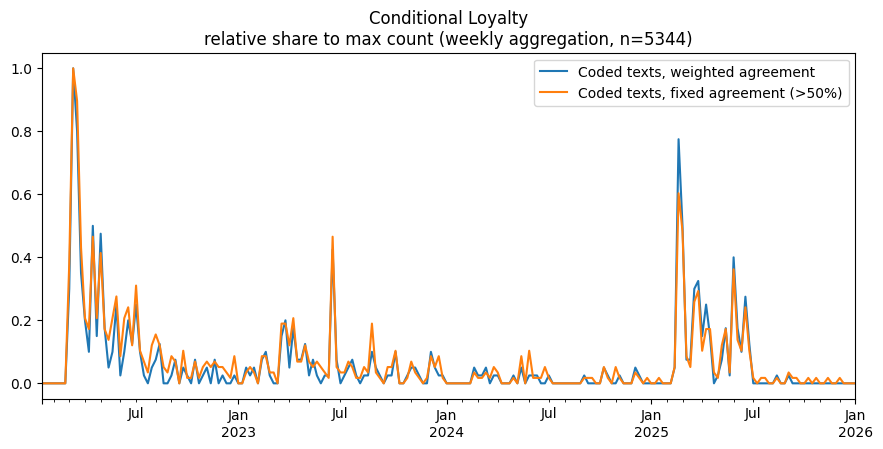

In [10]:
fig = plt.figure(figsize=(10.5, 4.5))
ax = fig.add_subplot()
df = pd.read_csv("./results/full_agreement_code_conditional_loyalty.csv", parse_dates=["datetime"])
df['count'] = 1
df = df.copy().set_index('datetime').resample("1W").sum()
df['count'].plot(ax=ax, label='All texts')
(df['w_code_applied']+1).plot(ax=ax, label='Coded texts, weighted agreement')
(df['code_applied']+1).plot(ax=ax, label='Coded texts, fixed agreement (>50%)')
ax.set_title(f"Conditional Loyalty\ntext counts (weekly aggregation, logarithmic scale, n={df['count'].sum()})")
ax.set_xlabel(None)
ax.set_yscale('log')
ax.legend()

fig = plt.figure(figsize=(10.5, 4.5))
ax = fig.add_subplot()
df = pd.read_csv("./results/full_agreement_code_conditional_loyalty.csv", parse_dates=["datetime"])
df['count'] = 1
df = df.copy().set_index('datetime').resample("1W").sum()
#df['count'].cumsum().plot(ax=ax, label='All texts')
(df['w_code_applied']+1).cumsum().plot(ax=ax, label='Coded texts, weighted agreement')
(df['code_applied']+1).cumsum().plot(ax=ax, label='Coded texts, fixed agreement (>50%)')
ax.set_title(f"Conditional Loyalty\ntext cumulative counts (weekly aggregation, logarithmic scale, n={df['count'].sum()})")
ax.set_xlabel(None)
ax.set_yscale('log')
ax.legend()

fig = plt.figure(figsize=(10.5, 4.5))
ax = fig.add_subplot()
df = pd.read_csv("./results/full_agreement_code_conditional_loyalty.csv", parse_dates=["datetime"])
df['count'] = 1
df = df.copy().set_index('datetime').resample("1W").sum()
(df['w_code_applied'] / df['count']).plot(ax=ax, label='Coded texts, weighted agreement')
(df['code_applied'] / df['count']).plot(ax=ax, label='Coded texts, fixed agreement (>50%)')
ax.set_title(f"Conditional Loyalty\nrelative share to all texts (weekly aggregation, n={df['count'].sum()})")
ax.set_xlabel(None)
ax.legend()

fig = plt.figure(figsize=(10.5, 4.5))
ax = fig.add_subplot()
df = pd.read_csv("./results/full_agreement_code_conditional_loyalty.csv", parse_dates=["datetime"])
df['count'] = 1
df = df.copy().set_index('datetime').resample("1W").sum()
(df['w_code_applied'] / df['w_code_applied'].max()).plot(ax=ax, label='Coded texts, weighted agreement')
(df['code_applied'] / df['code_applied'].max()).plot(ax=ax, label='Coded texts, fixed agreement (>50%)')
ax.set_title(f"Conditional Loyalty\nrelative share to max count (weekly aggregation, n={df['count'].sum()})")
ax.set_xlabel(None)
ax.legend()

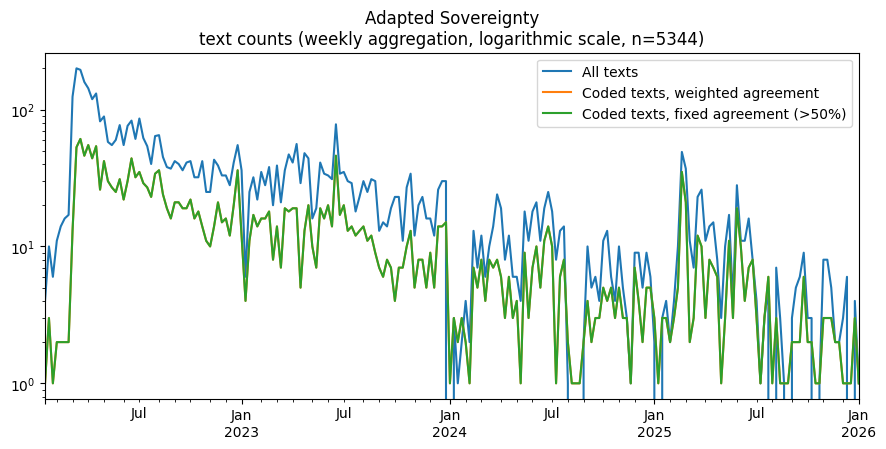

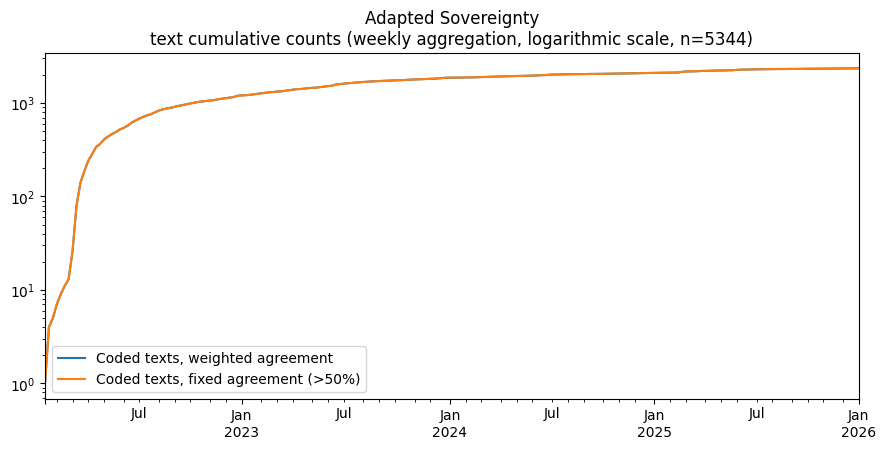

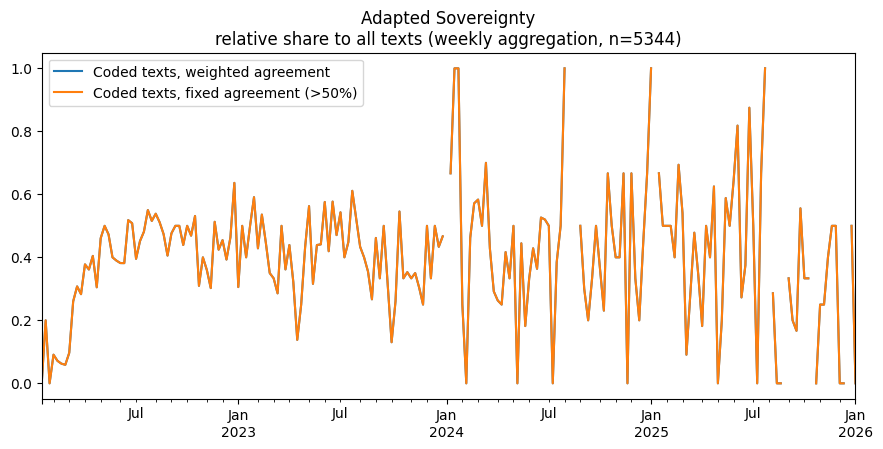

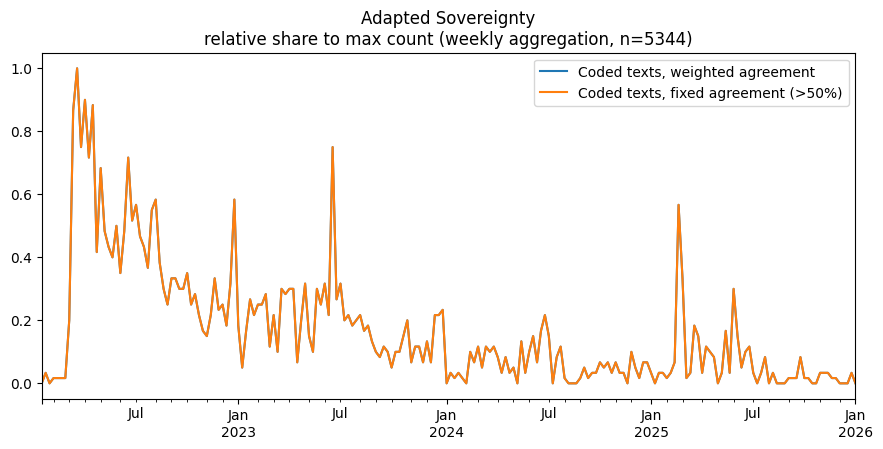

In [11]:
fig = plt.figure(figsize=(10.5, 4.5))
ax = fig.add_subplot()
df = pd.read_csv("./results/full_agreement_code_adapted_sovereignty.csv", parse_dates=["datetime"])
df['count'] = 1
df = df.copy().set_index('datetime').resample("1W").sum()
df['count'].plot(ax=ax, label='All texts')
(df['w_code_applied']+1).plot(ax=ax, label='Coded texts, weighted agreement')
(df['code_applied']+1).plot(ax=ax, label='Coded texts, fixed agreement (>50%)')
ax.set_title(f"Adapted Sovereignty\ntext counts (weekly aggregation, logarithmic scale, n={df['count'].sum()})")
ax.set_xlabel(None)
ax.set_yscale('log')
ax.legend()

fig = plt.figure(figsize=(10.5, 4.5))
ax = fig.add_subplot()
df = pd.read_csv("./results/full_agreement_code_adapted_sovereignty.csv", parse_dates=["datetime"])
df['count'] = 1
df = df.copy().set_index('datetime').resample("1W").sum()
#df['count'].cumsum().plot(ax=ax, label='All texts')
(df['w_code_applied']+1).cumsum().plot(ax=ax, label='Coded texts, weighted agreement')
(df['code_applied']+1).cumsum().plot(ax=ax, label='Coded texts, fixed agreement (>50%)')
ax.set_title(f"Adapted Sovereignty\ntext cumulative counts (weekly aggregation, logarithmic scale, n={df['count'].sum()})")
ax.set_xlabel(None)
ax.set_yscale('log')
ax.legend()

fig = plt.figure(figsize=(10.5, 4.5))
ax = fig.add_subplot()
df = pd.read_csv("./results/full_agreement_code_adapted_sovereignty.csv", parse_dates=["datetime"])
df['count'] = 1
df = df.copy().set_index('datetime').resample("1W").sum()
(df['w_code_applied'] / df['count']).plot(ax=ax, label='Coded texts, weighted agreement')
(df['code_applied'] / df['count']).plot(ax=ax, label='Coded texts, fixed agreement (>50%)')
ax.set_title(f"Adapted Sovereignty\nrelative share to all texts (weekly aggregation, n={df['count'].sum()})")
ax.set_xlabel(None)
ax.legend()

fig = plt.figure(figsize=(10.5, 4.5))
ax = fig.add_subplot()
df = pd.read_csv("./results/full_agreement_code_adapted_sovereignty.csv", parse_dates=["datetime"])
df['count'] = 1
df = df.copy().set_index('datetime').resample("1W").sum()
(df['w_code_applied'] / df['w_code_applied'].max()).plot(ax=ax, label='Coded texts, weighted agreement')
(df['code_applied'] / df['code_applied'].max()).plot(ax=ax, label='Coded texts, fixed agreement (>50%)')
ax.set_title(f"Adapted Sovereignty\nrelative share to max count (weekly aggregation, n={df['count'].sum()})")
ax.set_xlabel(None)
ax.legend()